In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
dataset_path = "Multi-class Weather Dataset"
categories = os.listdir(dataset_path)
for cat in categories:
    count = len(os.listdir(os.path.join(dataset_path, cat)))
    print(f"{cat}: {count} images")

Cloudy: 300 images
Rain: 215 images
Shine: 253 images
Sunrise: 357 images


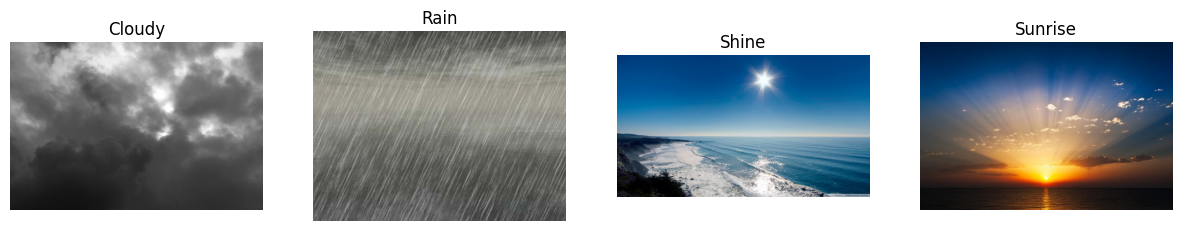

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for i, cat in enumerate(categories):
    img_path = os.path.join(dataset_path, cat, os.listdir(os.path.join(dataset_path, cat))[0])
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cat)
    axes[i].axis('off')
plt.show()

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Classes:", train_data.class_indices)


Found 901 images belonging to 4 classes.
Found 224 images belonging to 4 classes.
Classes: {'Cloudy': 0, 'Rain': 1, 'Shine': 2, 'Sunrise': 3}


In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze pretrained layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)     ┃ Output Shape   ┃  Param # ┃ Connected to   ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ input_layer      │ (None, 224,    │        0 │ -              │
│ (InputLayer)     │ 224, 3)        │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ Conv1 (Conv2D)   │ (None, 112,    │      864 │ input_layer[0… │
│                  │ 112, 32)       │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ bn_Conv1         │ (None, 112,    │      128 │ Conv1[0][0]    │
│ (BatchNormaliza… │ 112, 32)       │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ Conv1_relu       │ (None, 112,    │        0 │ bn_Conv1[0][0] │
│ (ReLU)           │ 112, 32)       │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ expanded_conv_d… │ (None, 112,    │      288 │ Conv1_relu[0]… │
│ (DepthwiseConv2… │ 112, 32)       │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ expanded_conv_d… │ (None, 112,    │      128 │ expanded_conv… │
│ (BatchNormaliza… │ 112, 32)       │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ expanded_conv_d… │ (None, 112,    │        0 │ expanded_conv… │
│ (ReLU)           │ 112, 32)       │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ expanded_conv_p… │ (None, 112,    │      512 │ expanded_conv… │
│ (Conv2D)         │ 112, 16)       │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ expanded_conv_p… │ (None, 112,    │       64 │ expanded_conv… │
│ (BatchNormaliza… │ 112, 16)       │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ block_1_expand   │ (None, 112,    │    1,536 │ expanded_conv… │
│ (Conv2D)         │ 112, 96)       │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ block_1_expand_… │ (None, 112,    │      384 │ block_1_expan… │
│ (BatchNormaliza… │ 112, 96)       │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ block_1_expand_… │ (None, 112,    │        0 │ block_1_expan… │
│ (ReLU)           │ 112, 96)       │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ block_1_pad      │ (None, 113,    │        0 │ block_1_expan… │
│ (ZeroPadding2D)  │ 113, 96)       │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ block_1_depthwi… │ (None, 56, 56, │      864 │ block_1_pad[0… │
│ (DepthwiseConv2… │ 96)            │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ block_1_depthwi… │ (None, 56, 56, │      384 │ block_1_depth… │
│ (BatchNormaliza… │ 96)            │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ block_1_depthwi… │ (None, 56, 56, │        0 │ block_1_depth… │
│ (ReLU)           │ 96)            │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ block_1_project  │ (None, 56, 56, │    2,304 │ block_1_depth… │
│ (Conv2D)         │ 24)            │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ block_1_project… │ (None, 56, 56, │       96 │ block_1_proje… │
│ (BatchNormaliza… │ 24)            │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ block_2_expand   │ (None, 56, 56, │    3,456 │ block_1_proje… │
│ (Conv2D)         │ 144)           │          │                │
├──────────────────┼────────────────┼──────────┼────────────────┤
│ block_2_expand_… │ (None, 56, 56, │   

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.7891 - loss: 0.5553 - val_accuracy: 0.8571 - val_loss: 0.3334
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9279 - loss: 0.2037 - val_accuracy: 0.8705 - val_loss: 0.3428
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9334 - loss: 0.1796 - val_accuracy: 0.8929 - val_loss: 0.2604
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9545 - loss: 0.1219 - val_accuracy: 0.9152 - val_loss: 0.2001
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9578 - loss: 0.1257 - val_accuracy: 0.9062 - val_loss: 0.2555
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9512 - loss: 0.1385 - val_accuracy: 0.9152 - val_loss: 0.2336
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9645 - loss: 0.0984 - val_accuracy: 0.9241 - val_loss: 0.2399


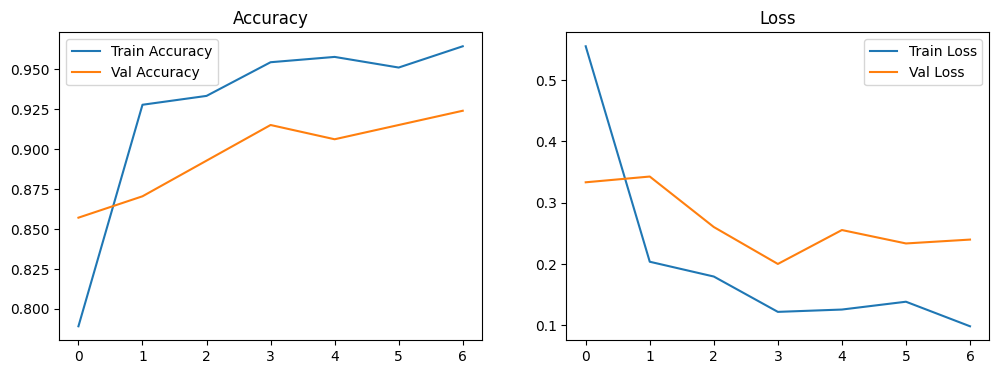

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [18]:
model.save("weather_model.keras")
print("Model saved!")

Model saved!


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


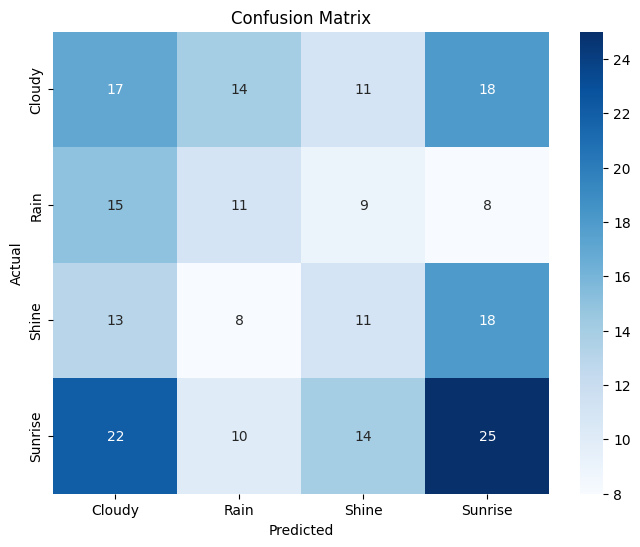

              precision    recall  f1-score   support

      Cloudy       0.25      0.28      0.27        60
        Rain       0.26      0.26      0.26        43
       Shine       0.24      0.22      0.23        50
     Sunrise       0.36      0.35      0.36        71

    accuracy                           0.29       224
   macro avg       0.28      0.28      0.28       224
weighted avg       0.29      0.29      0.29       224



In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

val_data.reset()
preds = model.predict(val_data)
y_pred = np.argmax(preds, axis=1)
y_true = val_data.classes

labels = list(train_data.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=labels))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


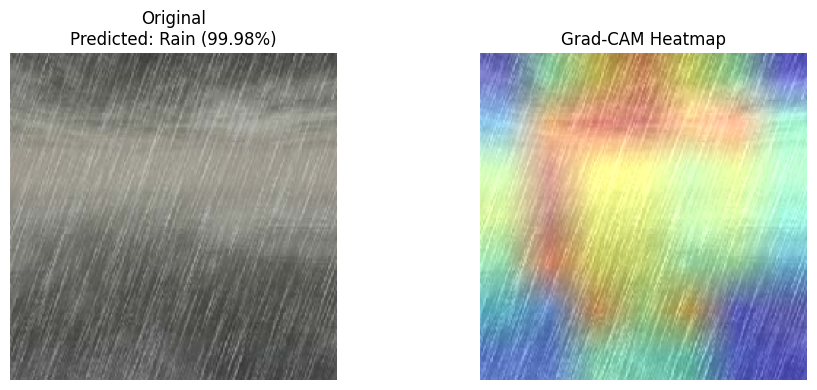

In [20]:
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

CLASS_NAMES = ['Cloudy', 'Rain', 'Shine', 'Sunrise']

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


def display_gradcam(img_path, model, last_conv_layer_name='out_relu'):
    # Load and prepare image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array_expanded = np.expand_dims(img_array, axis=0)

    # Get prediction
    predictions = model.predict(img_array_expanded)
    predicted_class = CLASS_NAMES[np.argmax(predictions)]
    confidence = round(float(np.max(predictions)) * 100, 2)

    # Generate heatmap
    heatmap = make_gradcam_heatmap(img_array_expanded, model, last_conv_layer_name)

    # Resize heatmap to match image
    heatmap_resized = np.uint8(255 * heatmap)
    heatmap_colored = cm.jet(heatmap_resized)[:, :, :3]
    heatmap_colored = tf.image.resize(heatmap_colored, (224, 224)).numpy()

    # Overlay heatmap on original image
    superimposed = heatmap_colored * 0.4 + img_array
    superimposed = np.clip(superimposed, 0, 1)

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img_array)
    axes[0].set_title(f"Original\nPredicted: {predicted_class} ({confidence}%)")
    axes[0].axis('off')

    axes[1].imshow(superimposed)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


# Test it on one image — pick any image from your dataset
sample_img_path = os.path.join(dataset_path, 'Rain', os.listdir(os.path.join(dataset_path, 'Rain'))[0])
display_gradcam(sample_img_path, model)